# PERTEMUAN 11
## Unsupervised Learning: Clustering (K-Means & Hierarchical)

**Nama:** Suryani Tangdiaga  
**NIM:** 250401020097  
**Kelas:** IF405  
**Program Studi:** Informatika

## Tujuan Pembelajaran

1. Memahami konsep **Unsupervised Learning**.
2. Membuat dataset sintetis pelanggan dengan beberapa kelompok tersembunyi.
3. Melakukan preprocessing menggunakan **StandardScaler**.
4. Menentukan jumlah cluster menggunakan **Elbow Method**.
5. Melatih model **K-Means Clustering**.
6. Mengevaluasi hasil clustering menggunakan **Silhouette Score**.
7. Membandingkan K-Means dengan **Hierarchical Clustering** menggunakan dendrogram.
8. Menginterpretasikan karakteristik setiap cluster sebagai segmentasi pelanggan.

## Langkah 1 — Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Membuat hasil yang konsisten
np.random.seed(42)

print("Library berhasil diimpor.")

Library berhasil diimpor.


## Langkah 2 — Generate & Eksplorasi Dataset

Dataset dibuat secara sintetis dengan tiga kelompok pelanggan:

- **Kelompok 1:** pelanggan hemat
- **Kelompok 2:** pelanggan menengah
- **Kelompok 3:** pelanggan boros

Fitur utama yang digunakan adalah **pendapatan tahunan** dan **skor belanja**.

Shape: (300, 4)

5 data pertama:


,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L



Statistik deskriptif:


,pendapatan_tahunan,skor_belanja,usia
count,300.00,300.00,300.00
mean,69.96,53.23,42.07
std,33.82,27.41,13.59
min,14.28,4.10,18.00
25%,32.14,25.60,30.00
50%,70.84,55.11,43.00
75%,103.40,78.16,53.00
max,140.79,103.17,64.00



Distribusi gender:
gender
L    165
P    135
Name: count, dtype: int64


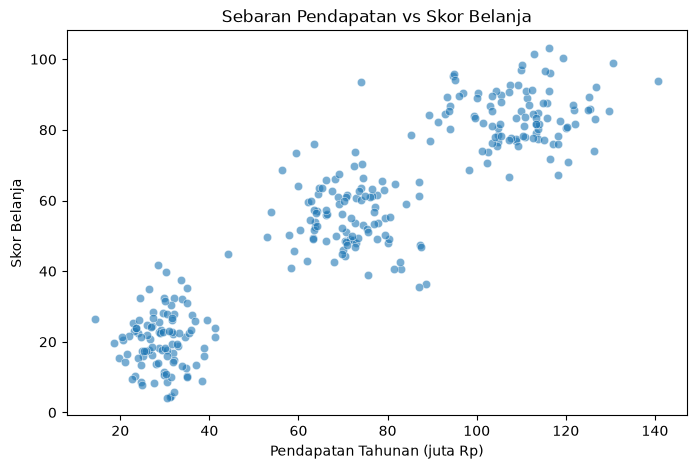

In [2]:
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))    # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(
    data,
    columns=["pendapatan_tahunan", "skor_belanja"]
)

df["usia"] = np.random.randint(18, 65, len(df))
df["gender"] = np.random.choice(["L", "P"], len(df))

print("Shape:", df.shape)
print("\n5 data pertama:")
display(df.head())

print("\nStatistik deskriptif:")
display(df.describe().round(2))

print("\nDistribusi gender:")
print(df["gender"].value_counts())

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="pendapatan_tahunan",
    y="skor_belanja",
    alpha=0.6
)
plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja")
plt.show()

## Langkah 3 — Preprocessing Data

Untuk proses clustering, kita menggunakan dua fitur numerik yang relevan:

- `pendapatan_tahunan`
- `skor_belanja`

StandardScaler digunakan agar kedua fitur memiliki skala yang setara.

In [3]:
X = df[["pendapatan_tahunan", "skor_belanja"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling:", X_scaled.mean(axis=0).round(3))
print("Std setelah scaling     :", X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling     : [1. 1.]


## Langkah 4 — Metode Elbow untuk Menentukan K

K-Means dijalankan dengan jumlah cluster **K = 1 sampai 10**. Nilai WCSS (Within-Cluster Sum of Squares) disimpan dan divisualisasikan dalam grafik Elbow.

Titik ketika penurunan WCSS mulai melandai dapat digunakan sebagai indikasi jumlah cluster yang sesuai.

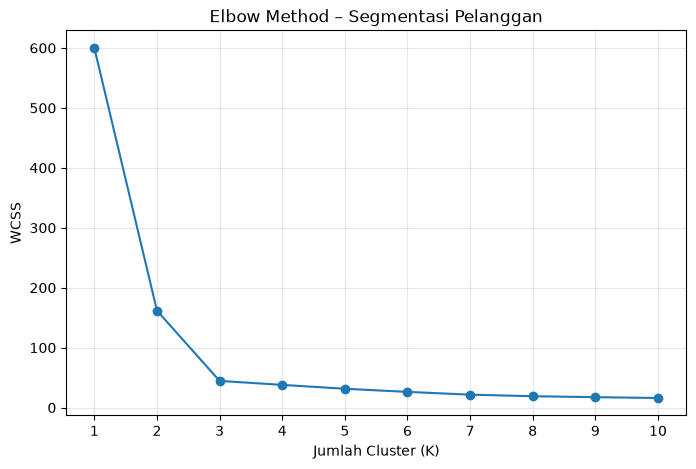

Nilai WCSS:
K=1: 600.00
K=2: 161.73
K=3: 44.56
K=4: 37.88
K=5: 31.45
K=6: 26.20
K=7: 21.56
K=8: 18.96
K=9: 17.39
K=10: 16.01


In [4]:
wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++",
        n_init=10
    )
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method – Segmentasi Pelanggan")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

print("Nilai WCSS:")
for k, value in enumerate(wcss, start=1):
    print(f"K={k}: {value:.2f}")

### Interpretasi Elbow

Berdasarkan pola grafik, kurva mulai melandai sekitar **K = 3**. Selain karena pola data memang dibuat dari tiga kelompok, K=3 juga memberikan segmentasi yang mudah diinterpretasikan.

## Langkah 5 — Melatih Model K-Means

Model K-Means dibuat dengan **3 cluster** berdasarkan hasil pengamatan Elbow Method.

In [5]:
model = KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++",
    n_init=10
)

model.fit(X_scaled)

df["cluster"] = model.labels_

sil_score = silhouette_score(X_scaled, model.labels_)

print(f"WCSS akhir       : {model.inertia_:.3f}")
print(f"Silhouette Score : {sil_score:.3f}")

print("\nJumlah anggota setiap cluster:")
print(df["cluster"].value_counts().sort_index())

print("\nRata-rata fitur setiap cluster:")
cluster_summary = (
    df.groupby("cluster")[["pendapatan_tahunan", "skor_belanja", "usia"]]
      .mean()
      .round(2)
)

display(cluster_summary)

WCSS akhir       : 44.556
Silhouette Score : 0.695

Jumlah anggota setiap cluster:
cluster
0     99
1    100
2    101
Name: count, dtype: int64

Rata-rata fitur setiap cluster:


,pendapatan_tahunan,skor_belanja,usia
cluster,,,
0,70.99,55.05,39.16
1,29.31,20.27,42.33
2,109.20,84.08,44.65


## Langkah 6 — Visualisasi Hasil Clustering

Visualisasi berikut menampilkan pelanggan berdasarkan cluster hasil K-Means. Posisi centroid dikembalikan ke skala data asli agar mudah diinterpretasikan.

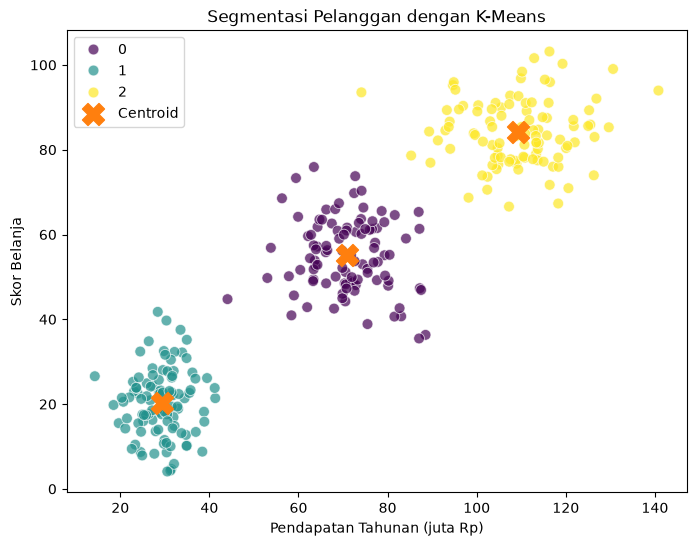

Koordinat centroid:


,pendapatan_tahunan,skor_belanja
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


In [6]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="pendapatan_tahunan",
    y="skor_belanja",
    hue="cluster",
    palette="viridis",
    alpha=0.7,
    s=60
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    label="Centroid"
)

plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan dengan K-Means")
plt.legend()
plt.show()

print("Koordinat centroid:")
centroid_df = pd.DataFrame(
    centroids,
    columns=["pendapatan_tahunan", "skor_belanja"]
)
display(centroid_df.round(2))

### Interpretasi Tiap Cluster

Karena nomor cluster dari K-Means dapat berubah, interpretasi dilakukan berdasarkan nilai rata-rata pendapatan dan skor belanja.

- **Cluster dengan pendapatan dan belanja paling rendah** → pelanggan **Hemat**.
- **Cluster dengan nilai menengah** → pelanggan **Menengah**.
- **Cluster dengan pendapatan dan belanja paling tinggi** → pelanggan **Boros**.

Nomor cluster dapat berbeda pada setiap implementasi, sehingga karakteristik berdasarkan centroid lebih penting daripada nomor cluster.

## Langkah 7 — Hierarchical Clustering (Pembanding)

Sebagai pembanding, digunakan **Hierarchical Clustering** dengan metode **Ward Linkage**. Hasilnya divisualisasikan menggunakan dendrogram.

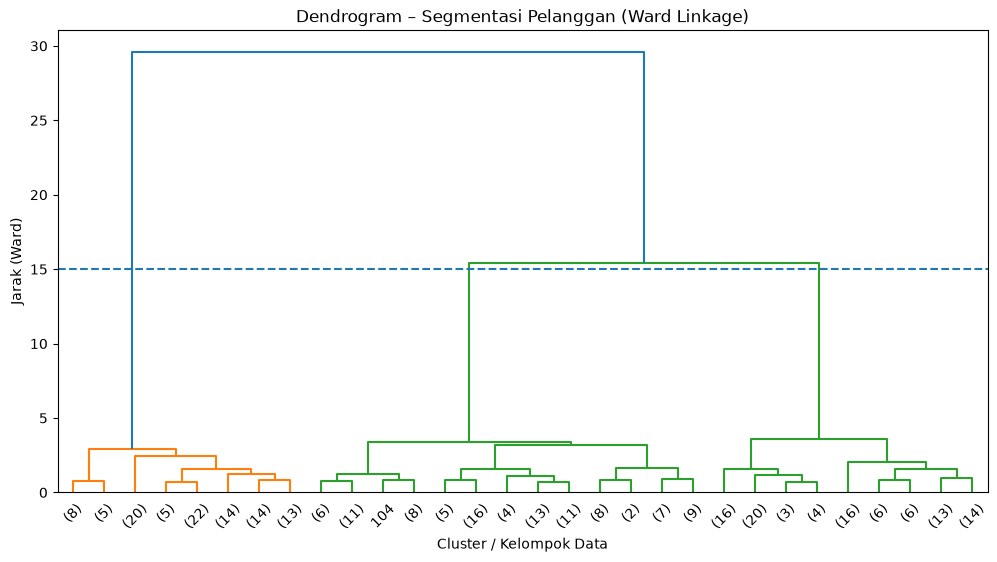

In [7]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    show_leaf_counts=True
)
plt.title("Dendrogram – Segmentasi Pelanggan (Ward Linkage)")
plt.xlabel("Cluster / Kelompok Data")
plt.ylabel("Jarak (Ward)")
plt.axhline(y=15, linestyle="--")
plt.show()

### Perbandingan K-Means dan Hierarchical Clustering

**K-Means** secara langsung membagi data menjadi sejumlah cluster tertentu, dalam praktikum ini K=3. Metode ini sederhana dan efisien untuk dataset dengan jumlah data yang cukup besar.

**Hierarchical Clustering** membangun struktur pengelompokan bertingkat yang dapat dilihat melalui dendrogram. Dendrogram membantu melihat hubungan kedekatan antar kelompok dan menentukan jumlah cluster berdasarkan titik pemotongan.

Pada dataset praktikum ini, kedua pendekatan diharapkan menghasilkan segmentasi yang secara umum sejalan, yaitu kelompok pelanggan dengan karakteristik **hemat, menengah, dan boros**.

## Kesimpulan

Berdasarkan praktikum yang telah dilakukan, K-Means berhasil mengelompokkan pelanggan berdasarkan pendapatan tahunan dan skor belanja menjadi tiga kelompok. Elbow Method menunjukkan bahwa K=3 merupakan pilihan yang sesuai dengan struktur dataset. Silhouette Score digunakan untuk melihat kualitas pemisahan antar cluster, dengan nilai yang semakin mendekati 1 menunjukkan cluster yang semakin baik terpisah.

Hasil clustering dapat digunakan untuk melakukan segmentasi pelanggan, misalnya pelanggan dengan pendapatan dan skor belanja rendah dikategorikan sebagai pelanggan hemat, kelompok dengan nilai menengah sebagai pelanggan menengah, dan kelompok dengan nilai tinggi sebagai pelanggan boros. Hierarchical Clustering melalui dendrogram memberikan pembanding yang membantu melihat struktur hubungan antar data.